In [20]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense , Dropout
from keras.models import Sequential
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("ushape.csv")

In [3]:
x = df.iloc[:, 0:2]
y = df.iloc[:, -1]

In [29]:
model = Sequential()

model.add(Dense(256, activation='relu', input_dim=2,
          kernel_initializer="he_normal"))
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu', kernel_initializer="he_normal"))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu', kernel_initializer="he_normal"))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu', kernel_initializer="he_normal"))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid', kernel_initializer="he_normal"))

model.summary()

c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,033 (172.00 KB)

 Trainable params: 44,033 (172.00 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(loss='binary_crossentropy',
              optimizer='adam', metrics=['accuracy'])
history = model.fit(x, y, validation_split=0.2, epochs=200, verbose=False)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 936us/step


<Axes: >

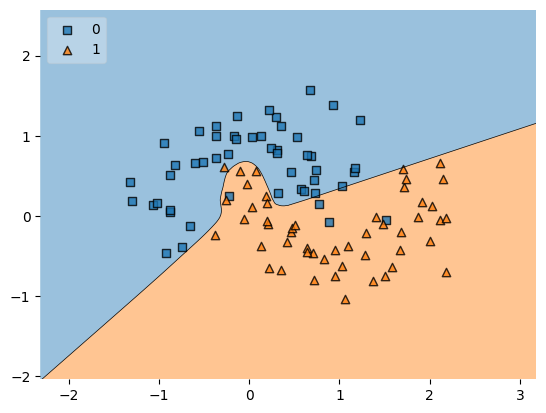

In [31]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.values, y.values.astype('int'), clf=model, legend=2)

In [33]:
np.mean(history.history['val_loss'])

np.float64(0.14301696132868527)

In [34]:
np.mean(history.history['loss'])

np.float64(0.26446700766682624)